In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define top 30 Indian stocks (NSE tickers on Yahoo Finance usually end with .NS)
tickers = ["RELIANCE.NS","TCS.NS","HDFCBANK.NS","ICICIBANK.NS","INFY.NS","HINDUNILVR.NS",
    "SBIN.NS","BHARTIARTL.NS","SUNPHARMA.NS","MARUTI.NS"]

# Step 2: Download last 5 years of daily closing prices
data = yf.download(tickers, start="2021-01-01", end="2026-01-01")['Close']


[*********************100%***********************]  10 of 10 completed


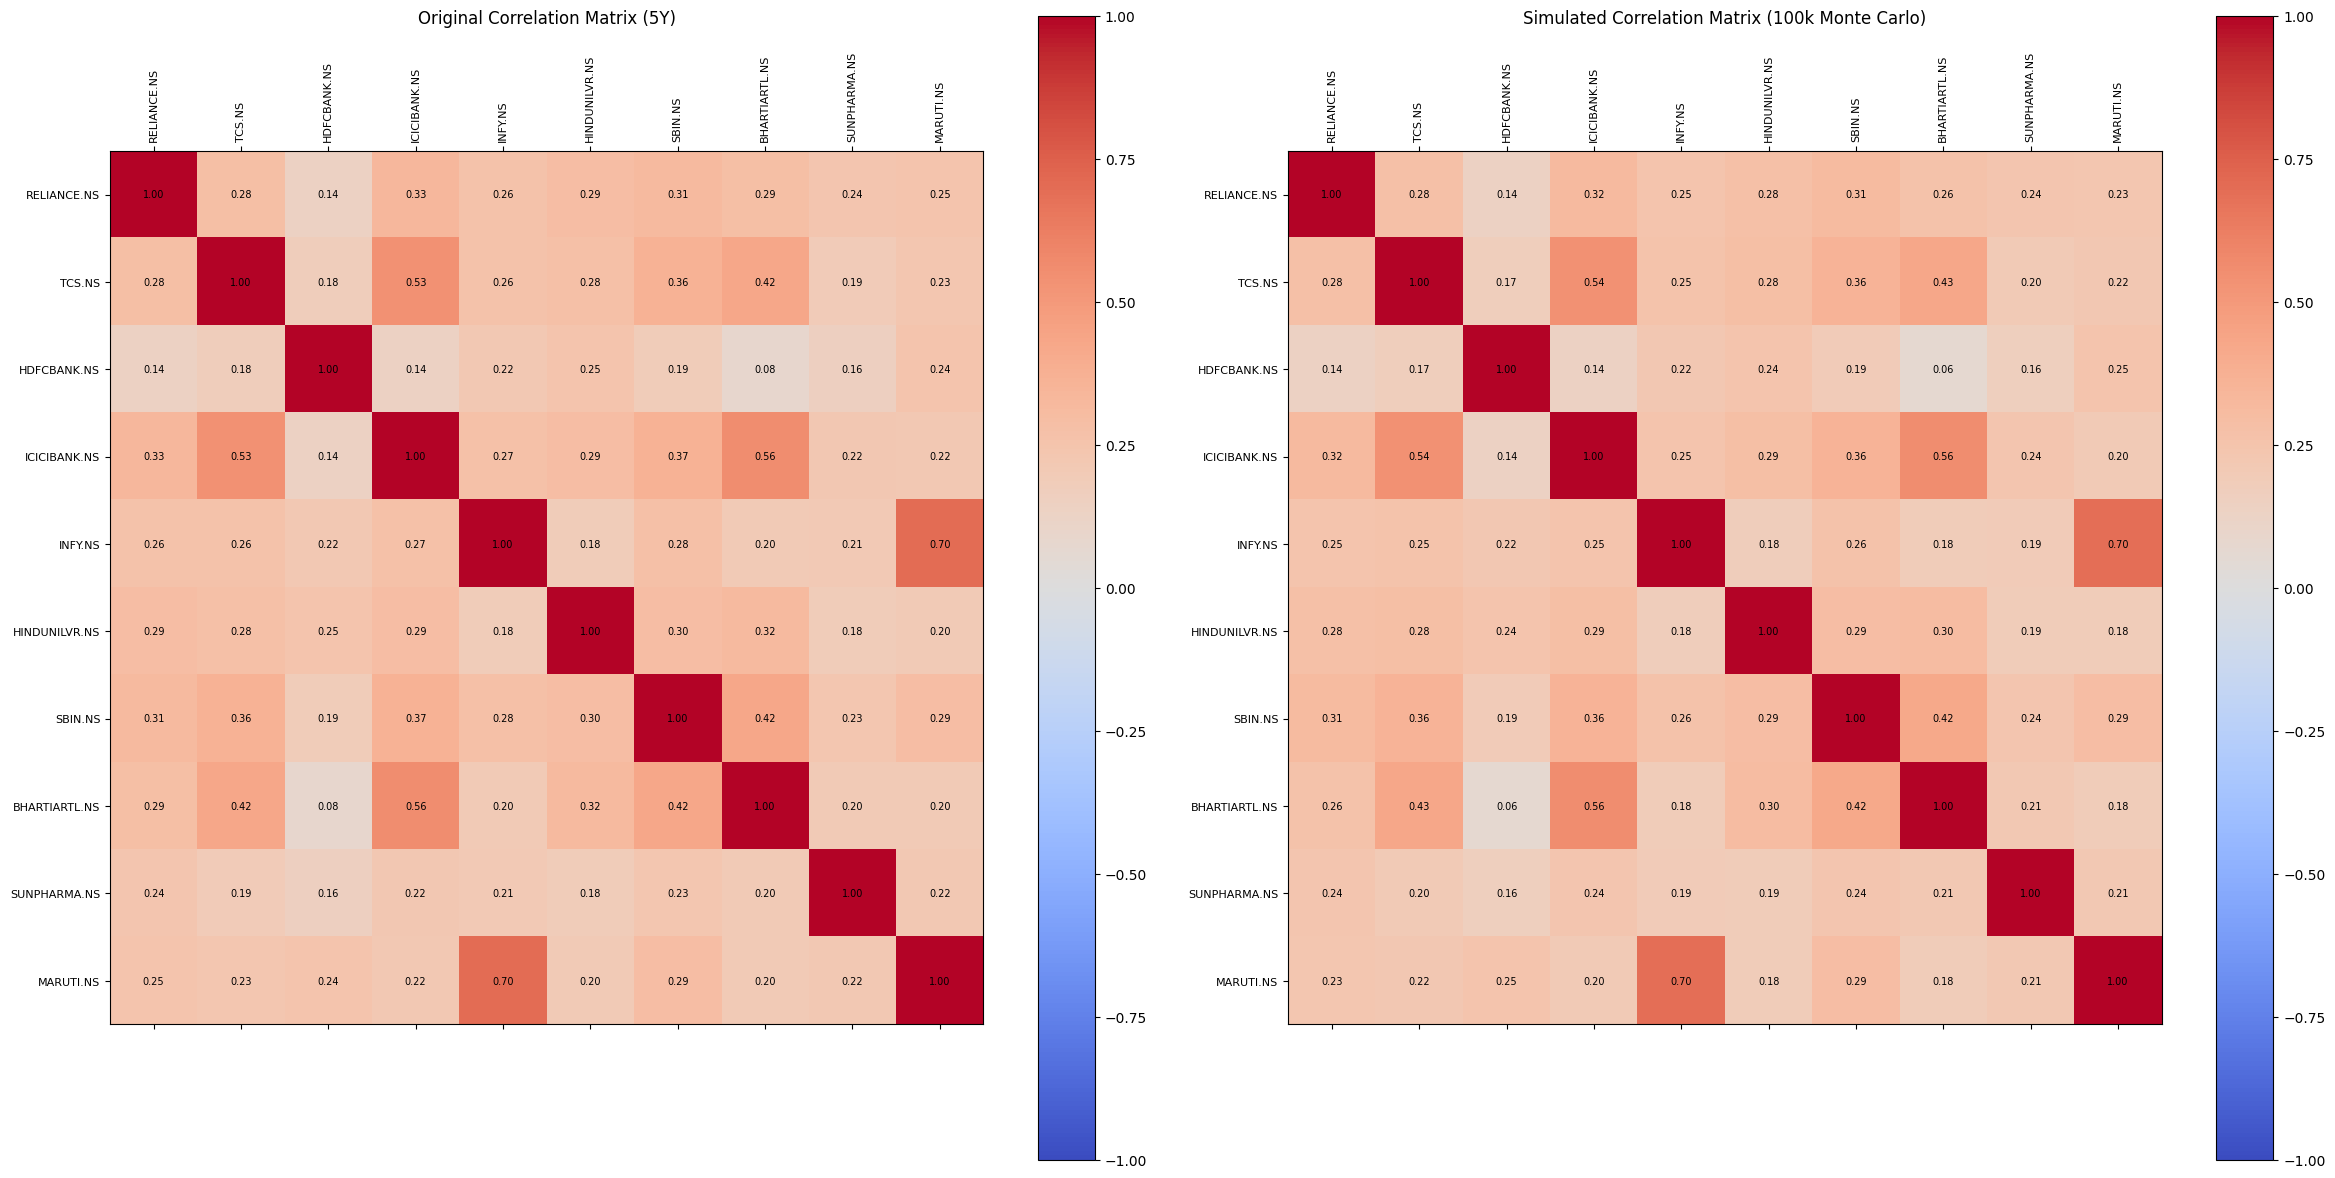

In [11]:

# Step 3: Compute returns and correlation matrix
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

# Step 4: Cholesky decomposition
L = np.linalg.cholesky(corr_matrix)

# Step 5: Monte Carlo simulation (100000 scenarios)
n_sims = 10000
n_assets = len(tickers)
Z = np.random.normal(size=(n_sims, n_assets))
simulated = Z @ L.T   # correlated shocks

# Step 6: Compute new correlation matrix from simulated scenarios
sim_corr = np.corrcoef(simulated.T)

# Step 7: Plot original and simulated correlation matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Original correlations
cax1 = axes[0].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax1, ax=axes[0])
for (i, j), val in np.ndenumerate(np.round(corr_matrix, 2)):
    axes[0].text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=7)
axes[0].set_xticks(range(len(tickers)))
axes[0].set_xticklabels(tickers, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(tickers)))
axes[0].set_yticklabels(tickers, fontsize=8)
axes[0].set_title("Original Correlation Matrix (5Y)", pad=20)

# Simulated correlations
cax2 = axes[1].matshow(sim_corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax2, ax=axes[1])
for (i, j), val in np.ndenumerate(np.round(sim_corr, 2)):
    axes[1].text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=7)
axes[1].set_xticks(range(len(tickers)))
axes[1].set_xticklabels(tickers, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(tickers)))
axes[1].set_yticklabels(tickers, fontsize=8)
axes[1].set_title("Simulated Correlation Matrix (100k Monte Carlo)", pad=20)

plt.tight_layout()
plt.show()